In [7]:
import sys
import requests
import re
import matplotlib.pyplot as plt


# contact.txt and ws4_script.py should be at same location.
# contact.txt is a command line argument.
# e.g. python ws4_script.py contacts.txt
# output.txt file is getting created at same location as ws4_script.py file.
    

In [8]:
def post_req(url, name, email):
    response = requests.post(url, {"name": name, "email": email})
    return response.text

Number of Successfull attempts: 9
Number of Unsuccessfull attempts: 6


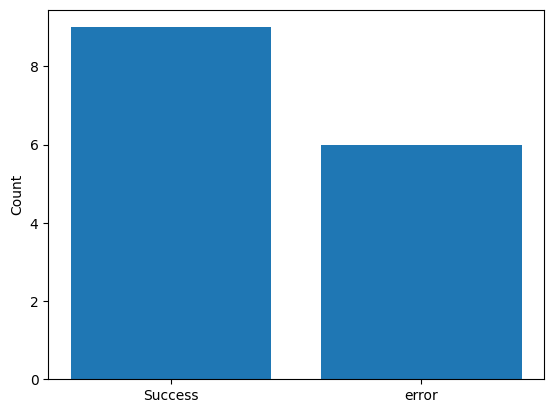

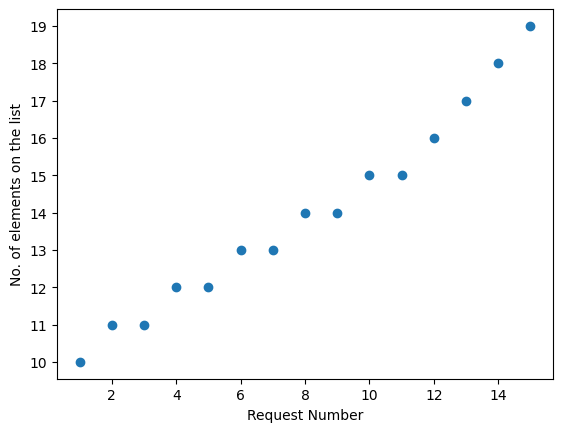

In [9]:
url = "http://localhost:8080/form"
#input_file = sys.argv[1]
input_file="contacts.txt"
succ = 0
err = 0
list_elements = []
sub = "Error"

f = open(input_file, "r")
lines = f.read().split("\n")
# print(lines)

for line in lines:
    name, email = line.split(",", 1)
    name = name.strip()
    email = email.strip().strip(",")
    message = post_req(url, name, email)
    # print(message)
    size = re.search(r"<em.*?>(.*?)</em>", message).group(1)
    # print(list_size)
    list_elements.append(size)

    msg = message.split("!")
    # print(msg[0])
    if sub in msg[0]:
        err += 1
    else:
        succ += 1

print("Number of Successfull attempts:", succ)
print("Number of Unsuccessfull attempts:", err)

x = ["Success", "error"]
y = [succ, err]
plt.bar(x, y)
plt.ylabel("Count")
plt.show()

cnt = 0
num = []
with open("output.txt", "w") as f:
    f.write("List elements: \n\n")
    for ele in list_elements:
        f.write(ele)
        cnt += 1
        num.append(cnt)
        f.write("\n")

plt.scatter(num, list_elements)
plt.ylabel("No. of elements on the list")
plt.xlabel("Request Number")
plt.show()
